# Bonus 02 - Time-series forecasting with MAPIE: intervals that move with the calendar

> "Friday's forecast is not exchangeable with Monday's." - Hearthstone finance, after the first cash-planning miss

The main course treated rows as shuffled listings. Forecasting is different: order carries
information, and tomorrow arrives after today no matter how much our theorem likes random
permutations. This bonus notebook shows how to think about conformal intervals for a
one-step-ahead time series forecast, using MAPIE's `TimeSeriesRegressor` when available
and the same reviewer habits from the rest of the course.

What you will learn:

- Why ordinary split conformal is an uneasy fit for ordered data.
- How lag features turn forecasting into a supervised regression table without leaking the
  future.
- How MAPIE's EnbPI-style time-series wrapper uses block bootstrap residuals and optional
  online updates.
- How to report coverage through a regime change without pretending the guarantee is the
  same as the exchangeable case.

Research trail: this notebook leans on the time-series discussion in Angelopoulos and
Bates, the original conformal exchangeability story from Vovk and Shafer, and MAPIE's
implementation of EnbPI-style forecasting based on Xu and Xie.


## 1. A cash forecast is a sequential product

Hearthstone's instant-offer desk needs a one-day-ahead cash forecast: how many millions of
dollars might be committed tomorrow? The point forecast is useful, but the finance team
needs an interval because a too-low forecast means scrambling for liquidity and a too-high
forecast means idle cash.

The catch: the rows are not exchangeable. Weekends differ from weekdays, launches create
local shocks, and a miss today is evidence about tomorrow. We should still use conformal
ideas, but the review language must change from "exact distribution-free finite-sample
coverage under exchangeability" to "sequential interval method designed for dependent
series, monitored online."


In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

import mapie
from mapie.regression import TimeSeriesRegressor
from mapie.subsample import BlockBootstrap

# MAPIE 1.4 emits the same API-stability warning on every online update.
# We suppress the repeated warning after choosing the documented update path below.
warnings.filterwarnings("ignore", category=UserWarning, module="mapie")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260707
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED"
)
alpha = 0.10
print(f"mapie version: {mapie.__version__}")


def coverage_score(y_true, lo, hi):
    return float(np.mean((y_true >= lo) & (y_true <= hi)))

def mean_width_score(lo, hi):
    return float(np.mean(hi - lo))


mapie version: 1.4.1


## 2. Build a forecast table without leaking tomorrow

The target is tomorrow's cash demand. The features are facts known at forecast time:
calendar terms, a planned-marketing flag, temperature-like market heat, and lagged demand.
The split is chosen so the launch shock starts in the test stream, not inside the
calibration window. That way the ordinary split-conformal baseline has to face exactly the
kind of ordered shift this notebook is about.


In [2]:
def simulate_cash_series(n_days=900, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    date = pd.date_range("2024-01-01", periods=n_days, freq="D")
    t = np.arange(n_days)
    weekday = date.weekday
    weekly = 0.55 * np.sin(2 * np.pi * weekday / 7) - 0.25 * (weekday >= 5)
    annual = 0.45 * np.sin(2 * np.pi * t / 365)
    launch = ((t > 650) & (t < 730)).astype(float)
    promo = rng.binomial(1, 0.08 + 0.07 * launch, size=n_days)
    heat = 0.8 * annual + 0.25 * rng.normal(size=n_days)

    demand = np.zeros(n_days)
    demand[:14] = 28 + rng.normal(0, 1.5, size=14)
    for i in range(14, n_days):
        drift = 0.012 * i + 2.8 * launch[i]
        sigma = 1.2 + 0.9 * launch[i] + 0.15 * max(demand[i - 1] - 35, 0)
        demand[i] = (
            21.0 + drift + 0.46 * demand[i - 1] + 0.16 * demand[i - 7]
            + 2.6 * promo[i] + 1.8 * heat[i] + weekly[i]
            + rng.normal(0, sigma)
        )
    return pd.DataFrame({
        "date": date,
        "demand_m": demand,
        "weekday": weekday,
        "promo": promo,
        "market_heat": heat,
        "launch": launch,
    })


def make_lagged_table(raw):
    df = raw.copy()
    df["t"] = np.arange(len(df))
    df["sin_week"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["cos_week"] = np.cos(2 * np.pi * df["weekday"] / 7)
    for lag in [1, 2, 7, 14]:
        df[f"lag_{lag}"] = df["demand_m"].shift(lag)
    df["rolling_7"] = df["demand_m"].shift(1).rolling(7).mean()
    df = df.dropna().reset_index(drop=True)
    features = ["t", "sin_week", "cos_week", "promo", "market_heat", "lag_1", "lag_2", "lag_7", "lag_14", "rolling_7"]
    return df, features

raw = simulate_cash_series()
df, features = make_lagged_table(raw)
train_end, calib_end = 520, 630
train_df = df.iloc[:train_end]
cal_df = df.iloc[train_end:calib_end]
test_df = df.iloc[calib_end:]

X_train, y_train = train_df[features].to_numpy(), train_df["demand_m"].to_numpy()
X_cal, y_cal = cal_df[features].to_numpy(), cal_df["demand_m"].to_numpy()
X_test, y_test = test_df[features].to_numpy(), test_df["demand_m"].to_numpy()

print(f"rows after lagging: {len(df):,}")
print(f"chronological split: train={len(train_df)}, calibration/update warmup={len(cal_df)}, test={len(test_df)}")
print(f"launch days in calibration/test: {int(cal_df['launch'].sum())} / {int(test_df['launch'].sum())}")
df.head(3)


rows after lagging: 886
chronological split: train=520, calibration/update warmup=110, test=256
launch days in calibration/test: 0 / 79


,date,demand_m,weekday,promo,market_heat,launch,t,sin_week,cos_week,lag_1,lag_2,lag_7,lag_14,rolling_7
0,2024-01-15,37.166017,0,0,-0.117723,0.0,14,0.000000,1.000000,29.683371,27.109378,28.163390,28.387605,28.665397
1,2024-01-16,43.955850,1,0,0.115228,0.0,15,0.781831,0.623490,37.166017,29.683371,29.011399,26.786650,29.951487
2,2024-01-17,40.278298,2,0,0.121652,0.0,16,0.974928,-0.222521,43.955850,37.166017,29.436831,28.145119,32.086409


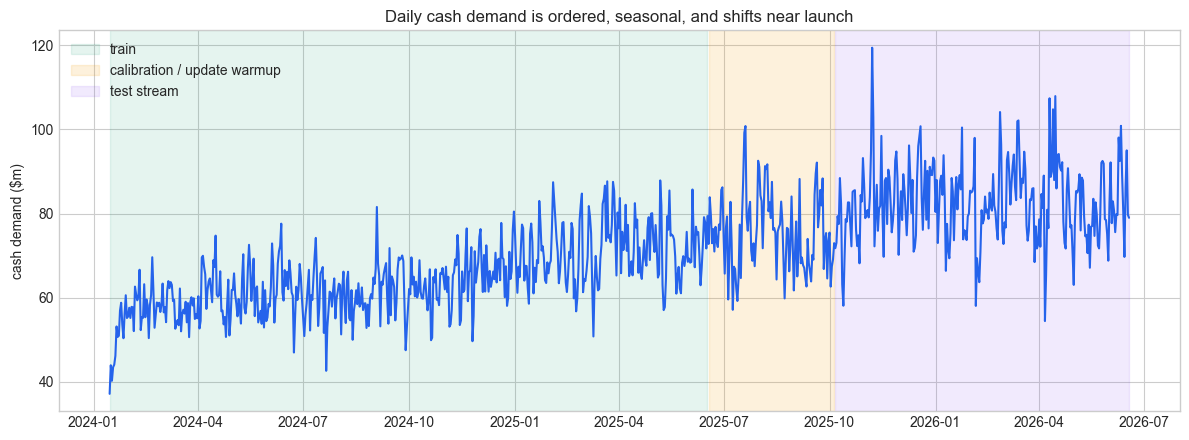

In [3]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df["date"], df["demand_m"], color=BLUE, linewidth=1.5)
ax.axvspan(train_df["date"].iloc[0], train_df["date"].iloc[-1], color=GREEN, alpha=0.10, label="train")
ax.axvspan(cal_df["date"].iloc[0], cal_df["date"].iloc[-1], color=AMBER, alpha=0.14, label="calibration / update warmup")
ax.axvspan(test_df["date"].iloc[0], test_df["date"].iloc[-1], color=PURPLE, alpha=0.10, label="test stream")
ax.set_title("Daily cash demand is ordered, seasonal, and shifts near launch")
ax.set_ylabel("cash demand ($m)")
ax.legend(loc="upper left")
plt.tight_layout()


## 3. The uncomfortable baseline: ordinary split conformal

If we ignore the time ordering, we can fit on the training window, calibrate on the next
window, and forecast the final stream with one fixed residual quantile. This is a useful
baseline and a useful warning. It is the notebook 02 recipe, but its assumption is not the
forecasting assumption.


In [4]:
base = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=4,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
base.fit(X_train, y_train)
cal_pred = base.predict(X_cal)
test_pred = base.predict(X_test)

scores = np.abs(y_cal - cal_pred)
q_level = math.ceil((len(scores) + 1) * (1 - alpha)) / len(scores)
q_split = np.quantile(scores, q_level, method="higher")
lo_split = test_pred - q_split
hi_split = test_pred + q_split

print(f"baseline test MAE: {mean_absolute_error(y_test, test_pred):.2f} million")
print(f"ordinary split conformal coverage: {np.mean((y_test >= lo_split) & (y_test <= hi_split)):.3f}")
print(f"ordinary split conformal mean width: {np.mean(hi_split - lo_split):.2f} million")


baseline test MAE: 10.78 million
ordinary split conformal coverage: 0.844
ordinary split conformal mean width: 36.02 million


## 4. MAPIE's time-series wrapper

MAPIE's `TimeSeriesRegressor` uses block bootstrap resampling for EnbPI-style intervals.
The block bootstrap is the key design choice: it resamples consecutive chunks instead of
pretending individual days can be shuffled independently. MAPIE also exposes `update`, so
new observed residuals can replace old ones as the stream unfolds.


In [5]:
# Fit MAPIE on the historical portion up through the warmup window. In a real forecast,
# this is the block available before the held-out stream starts.
X_hist = np.vstack([X_train, X_cal])
y_hist = np.concatenate([y_train, y_cal])

cv = BlockBootstrap(n_resamplings=25, length=28, random_state=RANDOM_SEED)
ts_no_update = TimeSeriesRegressor(
    RandomForestRegressor(n_estimators=90, min_samples_leaf=4, random_state=RANDOM_SEED, n_jobs=-1),
    method="enbpi",
    cv=cv,
    agg_function="mean",
    random_state=RANDOM_SEED,
)
ts_no_update.fit(X_hist, y_hist)
y_pred_ts, intervals_ts = ts_no_update.predict(X_test, ensemble=True, confidence_level=1 - alpha)
lo_ts = intervals_ts[:, 0, 0]
hi_ts = intervals_ts[:, 1, 0]

print(f"TimeSeriesRegressor, no online update: coverage={coverage_score(y_test, lo_ts, hi_ts):.3f}, "
      f"width={mean_width_score(lo_ts, hi_ts):.2f} million")


TimeSeriesRegressor, no online update: coverage=0.816, width=22.47 million


The no-update version is a better forecasting object than a shuffled-row story because its
resampling scheme respects short runs of time. It is still not magic: when the launch
shock begins, both the point forecast and the interval ledger are learning a new regime.
The online `update` pass lets newly observed misses enter tomorrow's interval calculation,
which is the behavior finance actually needs from a live forecaster.


In [6]:
ts_update = TimeSeriesRegressor(
    RandomForestRegressor(n_estimators=90, min_samples_leaf=4, random_state=RANDOM_SEED, n_jobs=-1),
    method="enbpi",
    cv=BlockBootstrap(n_resamplings=25, length=28, random_state=RANDOM_SEED),
    agg_function="mean",
    random_state=RANDOM_SEED,
)
ts_update.fit(X_hist, y_hist)

pred_update = []
lo_update = []
hi_update = []
for i in range(len(X_test)):
    y_i, int_i = ts_update.predict(X_test[i:i + 1], ensemble=True, confidence_level=1 - alpha)
    pred_update.append(float(y_i[0]))
    lo_update.append(float(int_i[0, 0, 0]))
    hi_update.append(float(int_i[0, 1, 0]))
    ts_update.update(X_test[i:i + 1], y_test[i:i + 1])

pred_update = np.array(pred_update)
lo_update = np.array(lo_update)
hi_update = np.array(hi_update)

report = pd.DataFrame({
    "method": ["ordinary split baseline", "MAPIE EnbPI no update", "MAPIE EnbPI with update"],
    "coverage": [
        np.mean((y_test >= lo_split) & (y_test <= hi_split)),
        coverage_score(y_test, lo_ts, hi_ts),
        coverage_score(y_test, lo_update, hi_update),
    ],
    "mean_width_m": [
        np.mean(hi_split - lo_split),
        mean_width_score(lo_ts, hi_ts),
        mean_width_score(lo_update, hi_update),
    ],
    "mae_m": [
        mean_absolute_error(y_test, test_pred),
        mean_absolute_error(y_test, y_pred_ts),
        mean_absolute_error(y_test, pred_update),
    ],
})
report.round(3)


,method,coverage,mean_width_m,mae_m
0,ordinary split baseline,0.844,36.023,10.780
1,MAPIE EnbPI no update,0.816,22.469,7.107
2,MAPIE EnbPI with update,0.859,24.055,7.107


The right interpretation is cautious. These numbers are empirical on one simulated stream,
not a universal theorem. The important contrast is that the ordinary split baseline was
calibrated before the launch shock and under-covered the launch-heavy test stream. The
time-series methods also need monitoring, but at least they are built around ordered
residuals and online updates rather than a pretend shuffle.


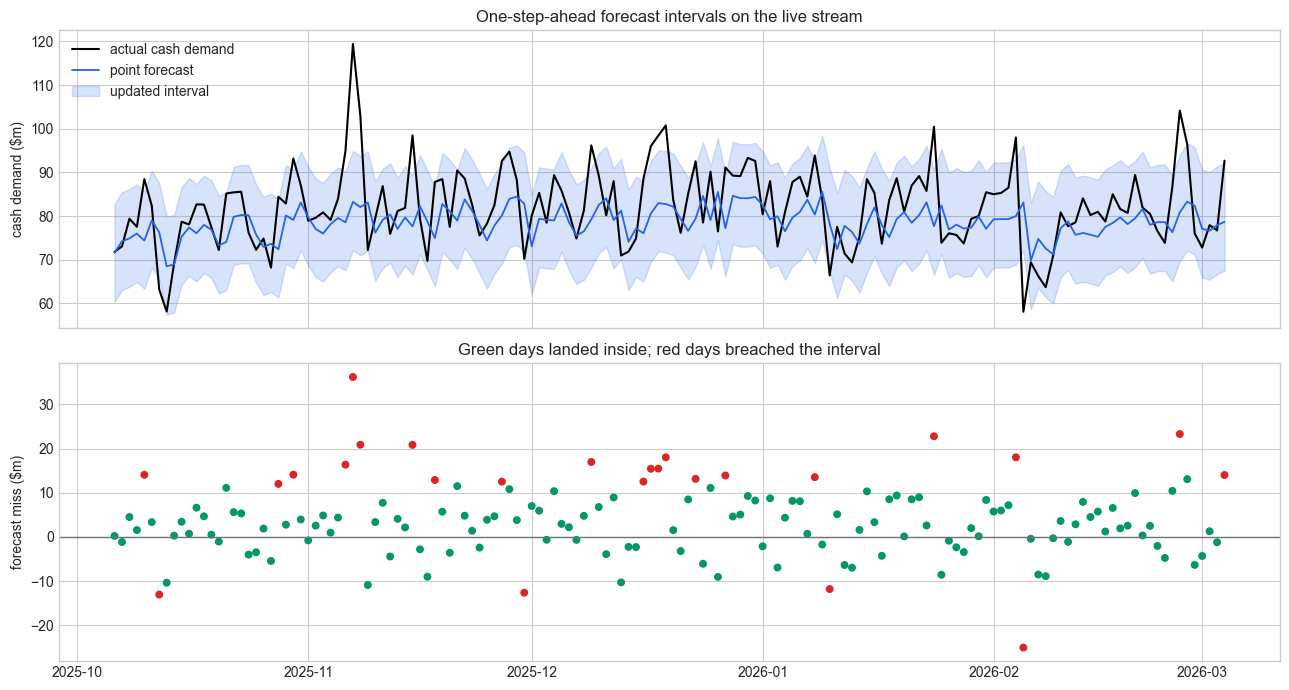

In [7]:
show = slice(0, min(150, len(y_test)))
dates = test_df["date"].iloc[show]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(dates, y_test[show], color="black", linewidth=1.5, label="actual cash demand")
axes[0].plot(dates, pred_update[show], color=BLUE, linewidth=1.3, label="point forecast")
axes[0].fill_between(dates, lo_update[show], hi_update[show], color=BLUE, alpha=0.18, label="updated interval")
axes[0].set_title("One-step-ahead forecast intervals on the live stream")
axes[0].set_ylabel("cash demand ($m)")
axes[0].legend(loc="upper left")

hit = (y_test >= lo_update) & (y_test <= hi_update)
axes[1].scatter(dates, y_test[show] - pred_update[show], c=np.where(hit[show], GREEN, RED), s=22)
axes[1].axhline(0, color=GRAY, linewidth=1)
axes[1].set_title("Green days landed inside; red days breached the interval")
axes[1].set_ylabel("forecast miss ($m)")
plt.tight_layout()


## 5. The forecast review

A time-series interval review should sound different from the exchangeable regression
review.

**Strong version:**

> We are using a time-series conformal wrapper rather than shuffled split conformal. The
> model uses only lagged and calendar features available at forecast time. The interval
> method uses block bootstrap residuals and updates its residual ledger as actuals arrive.
> We report rolling coverage and width, and we do not quote the exchangeable finite-sample
> theorem as if the rows were shuffled homes.

**Weak version:**

> It is conformal, so it is distribution-free.

That weak sentence is exactly how good theory gets over-sold. Time order changes the
assumption. The right product posture is still conformal, but humbler and better monitored.


### The one-line summary

Forecasting does not give you shuffled rows; MAPIE's time-series tools let you keep the
conformal habit - score, calibrate, monitor - while respecting the calendar that the
business actually lives on.
